In [ ]:
# @title Tahap 1: Instalasi & Import Library
# Instalasi mlxtend jika belum ada
!pip install mlxtend

# Import library yang dibutuhkan
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

print("Library yang dibutuhkan sudah siap.")

Library yang dibutuhkan sudah siap.


Tahap 2: Memuat dan Mempersiapkan Data Transaksi

In [ ]:
import pandas as pd

# Memuat dataset dari file CSV yang Anda unggah
file_path = '/content/Groceries_dataset.csv'
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk melihat struktur data
print("--- Tampilan Awal Data ---")
print(df.head())

# Membersihkan data dari spasi yang tidak perlu di nama item
df['itemDescription'] = df['itemDescription'].str.strip()

# Mengelompokkan item berdasarkan transaksi unik (kombinasi Member_number dan Date)
# dan membuat daftar transaksi (list of lists)
transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

# Menampilkan 5 transaksi pertama untuk verifikasi
print("\n--- 5 Transaksi Pertama Setelah Dikelompokkan ---")
for i in range(5):
    print(transactions[i])

--- Tampilan Awal Data ---
   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

--- 5 Transaksi Pertama Setelah Dikelompokkan ---
['sausage', 'whole milk', 'semi-finished bread', 'yogurt']
['whole milk', 'pastry', 'salty snack']
['canned beer', 'misc. beverages']
['sausage', 'hygiene articles']
['soda', 'pickled vegetables']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


Tahap 3: Transformasi Data ke Format One-Hot Encoding

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

# Membuat instance TransactionEncoder
te = TransactionEncoder()

# Melakukan fit dan transform pada data transaksi
te_ary = te.fit(transactions).transform(transactions)

# Mengubahnya menjadi DataFrame pandas
df_trans_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("\n--- Tampilan Data Setelah One-Hot Encoding (5 Baris Pertama) ---")
print(df_trans_encoded.head())


--- Tampilan Data Setelah One-Hot Encoding (5 Baris Pertama) ---
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  w

Tahap 4: Menjalankan Algoritma Apriori (Mencari Itemset Positif)

In [ ]:
from mlxtend.frequent_patterns import apriori

# Menjalankan algoritma Apriori
# Jika hasilnya kosong, coba turunkan nilai min_support (misal: 0.005)
min_support_threshold = 0.01
frequent_itemsets = apriori(df_trans_encoded, min_support=min_support_threshold, use_colnames=True)

print(f"\n--- Frequent Itemsets Ditemukan (dengan min_support >= {min_support_threshold}) ---")
print(f"Total itemsets yang ditemukan: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values(by='support', ascending=False).head(10)) # Menampilkan 10 teratas


--- Frequent Itemsets Ditemukan (dengan min_support >= 0.01) ---
Total itemsets yang ditemukan: 69
     support            itemsets
62  0.157923        (whole milk)
40  0.122101  (other vegetables)
46  0.110005        (rolls/buns)
52  0.097106              (soda)
63  0.085879            (yogurt)
47  0.069572   (root vegetables)
57  0.067767    (tropical fruit)
5   0.060683     (bottled water)
49  0.060349           (sausage)
15  0.053131      (citrus fruit)


Tahap 5: Mengidentifikasi dan Menghitung Aturan Asosiasi Negatif

In [ ]:
# Menetapkan ambang batas confidence
min_confidence_threshold = 0.5
negative_rules = []

# Mengambil itemset yang hanya berisi satu item (untuk perhitungan)
frequent_items_single = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: len(x) == 1)]

print("\n--- Proses Pencarian Aturan Negatif NON-TRIVIAL Dimulai ---")
print("(Mengabaikan pasangan item yang tidak pernah muncul bersama)")

# Iterasi untuk setiap pasangan item frequent
for _, row_A in frequent_items_single.iterrows():
    item_A_set = row_A['itemsets']
    item_A = list(item_A_set)[0]
    support_A = row_A['support']

    for _, row_B in frequent_items_single.iterrows():
        item_B_set = row_B['itemsets']
        item_B = list(item_B_set)[0]

        if item_A == item_B:
            continue

        # Cari support untuk itemset {A, B}
        itemset_AB = frozenset([item_A, item_B])
        support_AB_row = frequent_itemsets[frequent_itemsets['itemsets'] == itemset_AB]

        # MODIFIKASI DIMULAI DI SINI
        # Hanya proses jika pasangan item ini pernah muncul bersama (support > 0)
        if not support_AB_row.empty:
            support_AB = support_AB_row.iloc[0]['support']

            # Hitung support dan confidence untuk aturan negatif A -> ~B
            support_A_neg_B = support_A - support_AB
            confidence_A_neg_B = support_A_neg_B / support_A

            # Simpan aturan jika memenuhi ambang batas confidence
            if confidence_A_neg_B >= min_confidence_threshold:
                negative_rules.append({
                    'antecedent': item_A,
                    'consequent': f"~{item_B}",
                    'support': round(support_A_neg_B, 4),
                    'confidence': round(confidence_A_neg_B, 4),
                    'lift_negative': round(confidence_A_neg_B / (1-frequent_items_single.loc[row_B.name]['support']), 4) # Menambahkan lift
                })

print("--- Proses Selesai ---")


--- Proses Pencarian Aturan Negatif NON-TRIVIAL Dimulai ---
(Mengabaikan pasangan item yang tidak pernah muncul bersama)
--- Proses Selesai ---


Tahap 6 : Menampilkan dan Menganalisis Hasil

In [ ]:
if negative_rules:
    df_negative_rules = pd.DataFrame(negative_rules)

    print(f"\n--- DITEMUKAN {len(df_negative_rules)} ATURAN ASOSIASI NEGATIF (dengan min_confidence >= {min_confidence_threshold}) ---")

    # Menampilkan 15 aturan teratas berdasarkan confidence
    print(df_negative_rules.sort_values(by='confidence', ascending=False).head(15))
else:
    print(f"\n--- TIDAK ADA ATURAN NEGATIF YANG DITEMUKAN ---")
    print("Coba turunkan nilai min_confidence_threshold atau min_support_threshold.")


--- DITEMUKAN 10 ATURAN ASOSIASI NEGATIF (dengan min_confidence >= 0.5) ---
         antecedent         consequent  support  confidence  lift_negative
8        whole milk            ~yogurt   0.1468      0.9293         1.0166
7        whole milk              ~soda   0.1463      0.9264         1.0260
0  other vegetables        ~rolls/buns   0.1115      0.9135         1.0264
6        whole milk        ~rolls/buns   0.1440      0.9116         1.0242
5        whole milk  ~other vegetables   0.1431      0.9061         1.0321
2        rolls/buns  ~other vegetables   0.0994      0.9040         1.0297
4              soda        ~whole milk   0.0855      0.8802         1.0453
1  other vegetables        ~whole milk   0.1073      0.8785         1.0432
3        rolls/buns        ~whole milk   0.0960      0.8730         1.0368
9            yogurt        ~whole milk   0.0747      0.8700         1.0332


Tahap 7 : Visualisasi

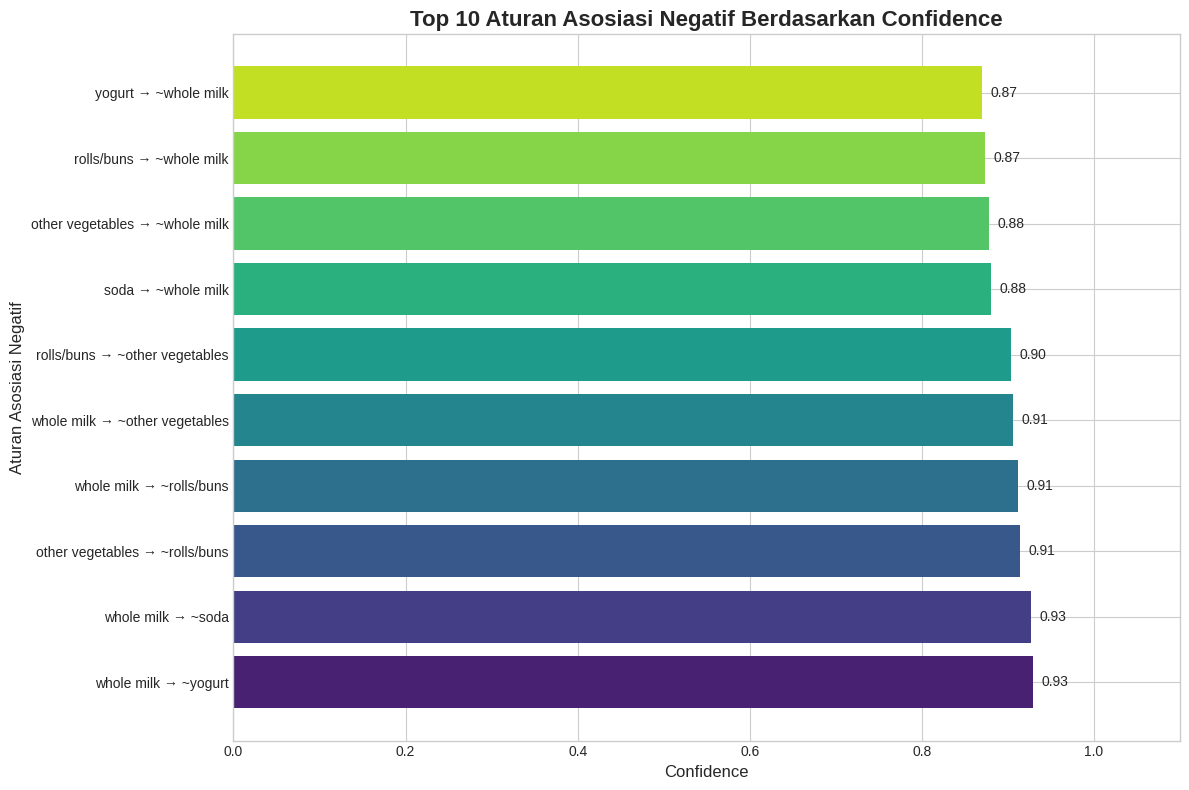

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Pastikan pandas diimpor

data = {
    'antecedent': ['whole milk', 'whole milk', 'other vegetables', 'whole milk', 'whole milk', 'rolls/buns', 'soda', 'other vegetables', 'rolls/buns', 'yogurt'],
    'consequent': ['~yogurt', '~soda', '~rolls/buns', '~rolls/buns', '~other vegetables', '~other vegetables', '~whole milk', '~whole milk', '~whole milk', '~whole milk'],
    'support': [0.1468, 0.1463, 0.1115, 0.1440, 0.1431, 0.0994, 0.0855, 0.1073, 0.0960, 0.0747],
    'confidence': [0.9293, 0.9264, 0.9135, 0.9116, 0.9061, 0.9040, 0.8802, 0.8785, 0.8730, 0.8700],
    'lift_negative': [1.0166, 1.0260, 1.0264, 1.0242, 1.0321, 1.0297, 1.0453, 1.0432, 1.0368, 1.0332]
}
df_negative_rules = pd.DataFrame(data)


# 1. PERSIAPAN DATA UNTUK VISUALISASI
# Urutkan data berdasarkan confidence dan ambil 10 aturan teratas
top_10_rules = df_negative_rules.sort_values(by='confidence', ascending=False).head(10)

# Buat label yang bagus untuk sumbu Y pada grafik
top_10_rules['rule_label'] = top_10_rules['antecedent'] + ' → ' + top_10_rules['consequent']


# 2. MEMBUAT GRAFIK
plt.style.use('seaborn-v0_8-whitegrid') # Menggunakan style agar grafik terlihat modern
fig, ax = plt.subplots(figsize=(12, 8)) # Mengatur ukuran gambar

# Membuat bar plot horizontal
bars = ax.barh(top_10_rules['rule_label'], top_10_rules['confidence'], color=sns.color_palette('viridis', 10))

# 3. MENAMBAHKAN JUDUL DAN LABEL
ax.set_title('Top 10 Aturan Asosiasi Negatif Berdasarkan Confidence', fontsize=16, fontweight='bold')
ax.set_xlabel('Confidence', fontsize=12)
ax.set_ylabel('Aturan Asosiasi Negatif', fontsize=12)

# Mengatur batas sumbu X agar ada ruang untuk label
ax.set_xlim(0, 1.1)

# Menambahkan label nilai confidence di setiap batang
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{width:.2f}',
            ha='left', va='center', fontsize=10)

plt.tight_layout() # Merapikan layout
plt.show() # Menampilkan grafik

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/Groceries_dataset.csv')

# Gabungkan kolom Member_number dan Date untuk identifikasi transaksi unik
df['Transaction'] = df['Member_number'].astype(str) + '_' + df['Date']

# Hitung jumlah transaksi unik
jumlah_transaksi_unik = df['Transaction'].nunique()

print(f"Jumlah transaksi unik: {jumlah_transaksi_unik}")


Jumlah transaksi unik: 14963
